# Gradients

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture
*"Gradients"* (Week 2 — Gradients and Gradient Descent).

This notebook explains:

- how to **condense all partial derivatives into a single vector** — the gradient
- the **nabla** notation $\nabla f$
- the worked example $\nabla f = (2x,\,2y)$ for $f(x,y)=x^2+y^2$, and its value $(4,6)$ at $(2,3)$
- generalization to functions of many variables
- the connection to the **tangent plane**
- the geometric meaning (direction of steepest increase), with a vector-field plot
- SymPy and numerical checks, exercises, and a summary

This notebook follows the repository `GUIDELINES.md` template and continues directly
from *Partial Derivatives - Part 1 & 2*.

## 1. Introduction

> *"I'm going to show you a nice way to condense all the partial derivatives into a
> vector known as the gradient."*

Once you know partial derivatives, the gradient is a tiny step away: it simply
**collects** them into one vector. That single object turns out to be the central
quantity in multivariable optimization — and therefore in training machine-learning
models via **gradient descent**.

After this notebook you will be able to:

- write the gradient of any differentiable function
- evaluate it at a point
- read the nabla notation $\nabla f$
- connect the gradient to the tangent plane and to steepest ascent

## 2. From partial derivatives to a vector

Recall that for a function of two variables you can slice it two ways — treating $y$ as a
constant, and treating $x$ as a constant — giving two partial derivatives. For

$$
f(x,y) = x^2 + y^2,
$$

$$
\frac{\partial f}{\partial x} = 2x, \qquad \frac{\partial f}{\partial y} = 2y .
$$

The **gradient** is simply the vector containing these partial derivatives:

$$
\nabla f = \begin{bmatrix} \dfrac{\partial f}{\partial x} \\[2mm] \dfrac{\partial f}{\partial y} \end{bmatrix}
= \begin{bmatrix} 2x \\ 2y \end{bmatrix}.
$$

### Notation

The gradient is written with the **nabla** symbol $\nabla$:

$$
\nabla f = \left( \frac{\partial f}{\partial x_1},\; \frac{\partial f}{\partial x_2},\; \dots,\; \frac{\partial f}{\partial x_n} \right).
$$

> *"That's just the collection of all the partial derivatives with respect to all the
> variables in the function."*

## 3. Worked example: gradient at a point

> *"Find the gradient of $f(x,y)$ at the point $(2, 3)$."*

Since $\nabla f = (2x,\, 2y)$, substitute $x=2$ and $y=3$:

$$
\nabla f(2, 3) = (2\cdot 2,\; 2\cdot 3) = (4,\, 6).
$$

So the gradient of $f(x,y)=x^2+y^2$ at $(2,3)$ is the vector $(4, 6)$.

## 4. Symbolic computation with SymPy

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

x, y = sp.symbols('x y')
f_sym = x**2 + y**2

grad = [sp.diff(f_sym, v) for v in (x, y)]
print("f(x, y) =", f_sym)
print("∇f      =", tuple(grad))                       # (2x, 2y)

grad_at = [g.subs({x: 2, y: 3}) for g in grad]
print("∇f(2,3) =", tuple(grad_at))                    # (4, 6)

f(x, y) = x**2 + y**2
∇f      = (2*x, 2*y)
∇f(2,3) = (4, 6)


### A function of many variables

> *"If the function has 17 variables, it would simply be a vector of 17 entries, each one
> corresponding to the partial derivative with respect to each variable."*

The gradient always has **one entry per variable**.

In [2]:
# Gradient of a 4-variable function — one entry per variable
vars4 = sp.symbols('x1 x2 x3 x4')
x1, x2, x3, x4 = vars4
g = x1**2 + 3*x2*x3 + sp.sin(x4)

gradient = sp.Matrix([sp.diff(g, v) for v in vars4])
print("g  =", g)
print("∇g =", gradient.T)   # row form for readability

g  = x1**2 + 3*x2*x3 + sin(x4)
∇g = Matrix([[2*x1, 3*x3, 3*x2, cos(x4)]])


## 5. Connection to the tangent plane

> *"The gradient $(2x, 2y)$ is a pretty good description of the tangent plane, because it
> describes the slopes of the two lines that form that tangent plane."*

Recall the tangent-plane equation from the earlier lecture:

$$
z = f(x_0,y_0) + \underbrace{f_x(x_0,y_0)}_{\text{1st component of } \nabla f}(x-x_0)
                 + \underbrace{f_y(x_0,y_0)}_{\text{2nd component of } \nabla f}(y-y_0).
$$

The two components of the gradient are exactly the slopes of the two tangent lines that
span the plane.

## 6. Numerical check

The gradient is just the pair of partial derivatives, so a central finite difference in
each direction should reproduce it.

In [3]:
def f(x, y):
    return x**2 + y**2

def gradient_numeric(f, x, y, h=1e-6):
    fx = (f(x + h, y) - f(x - h, y)) / (2 * h)
    fy = (f(x, y + h) - f(x, y - h)) / (2 * h)
    return np.array([fx, fy])

for (x0, y0) in [(2.0, 3.0), (1.0, 0.0), (-2.0, 1.0)]:
    num = gradient_numeric(f, x0, y0)
    exact = np.array([2*x0, 2*y0])
    print(f"At ({x0:>4}, {y0:>4}): ∇f numeric = {np.round(num,4)}   exact = {exact}")

At ( 2.0,  3.0): ∇f numeric = [4. 6.]   exact = [4. 6.]
At ( 1.0,  0.0): ∇f numeric = [2. 0.]   exact = [2. 0.]
At (-2.0,  1.0): ∇f numeric = [-4.  2.]   exact = [-4.  2.]


## 7. Visualizing the gradient field

For $f(x,y)=x^2+y^2$ the contours are circles. The gradient $\nabla f=(2x,2y)$ at each
point is an arrow that points **away from the origin** — i.e. in the direction in which
$f$ increases fastest (steepest ascent). This is the property that **gradient descent**
later exploits, by stepping in the *opposite* direction.

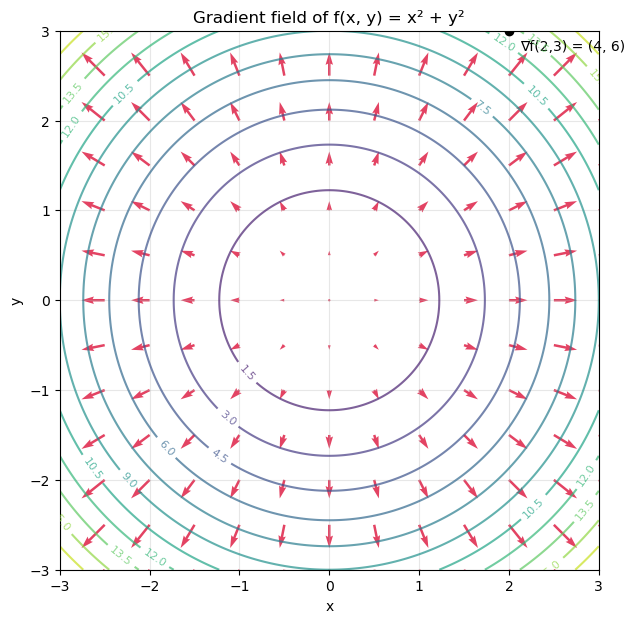

In [4]:
gx = np.linspace(-3, 3, 200)
gy = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(gx, gy)
Z = X**2 + Y**2

# gradient field on a coarser grid
qx = np.linspace(-3, 3, 13)
qy = np.linspace(-3, 3, 13)
QX, QY = np.meshgrid(qx, qy)
U, V = 2*QX, 2*QY     # ∇f = (2x, 2y)

plt.figure(figsize=(7, 7))
cs = plt.contour(X, Y, Z, levels=12, cmap="viridis", alpha=0.7)
plt.clabel(cs, inline=True, fontsize=8)
plt.quiver(QX, QY, U, V, color="crimson", alpha=0.8)

# highlight the worked point (2, 3) and its gradient (4, 6)
plt.plot(2, 3, "ko")
plt.quiver(2, 3, 4, 6, color="black", scale=40, width=0.008)
plt.annotate("∇f(2,3) = (4, 6)", (2, 3), textcoords="offset points", xytext=(8, -14))

plt.title("Gradient field of f(x, y) = x² + y²")
plt.xlabel("x"); plt.ylabel("y")
plt.gca().set_aspect("equal")
plt.grid(True, alpha=0.3)
plt.show()

## 8. Exercises

### Basic
1. Write the gradient $\nabla f$ for $f(x,y) = x^2 + y^2$.
2. Evaluate $\nabla f$ at the point $(1, 5)$.

### Intermediate
3. Find the gradient of $f(x,y) = 3x^2 y^3$ (from the previous lecture) and evaluate it at $(1, 1)$.
4. Find the gradient of $f(x,y) = x^2 + xy + y^2$ at $(1, 2)$.

### Advanced
5. Find the gradient of $g(x,y,z) = x^2 y + y z^2 + \sin(x)$.
6. At which point(s) is the gradient of $f(x,y)=x^2+y^2$ equal to the zero vector, and
   what is special about that point on the surface?

## 9. Solutions / Checks

In [5]:
x, y, z = sp.symbols('x y z')

def gradient(expr, vars):
    return tuple(sp.diff(expr, v) for v in vars)

f = x**2 + y**2
print("1. ∇f =", gradient(f, (x, y)))
print("2. ∇f(1,5) =", tuple(g.subs({x:1, y:5}) for g in gradient(f, (x, y))))

f3 = 3*x**2*y**3
print("3. ∇f =", gradient(f3, (x, y)),
      " at (1,1):", tuple(g.subs({x:1, y:1}) for g in gradient(f3, (x, y))))

f4 = x**2 + x*y + y**2
print("4. ∇f(1,2) =", tuple(g.subs({x:1, y:2}) for g in gradient(f4, (x, y))))

g5 = x**2*y + y*z**2 + sp.sin(x)
print("5. ∇g =", gradient(g5, (x, y, z)))

print("6. ∇f = (2x, 2y) = (0,0) only at (0,0); it is the minimum of the bowl.")

1. ∇f = (2*x, 2*y)
2. ∇f(1,5) = (2, 10)
3. ∇f = (6*x*y**3, 9*x**2*y**2)  at (1,1): (6, 9)
4. ∇f(1,2) = (4, 5)
5. ∇g = (2*x*y + cos(x), x**2 + z**2, 2*y*z)
6. ∇f = (2x, 2y) = (0,0) only at (0,0); it is the minimum of the bowl.


## 10. Conclusion

- The **gradient** $\nabla f$ collects all of a function's partial derivatives into one
  vector — **one entry per variable**.
- For $f(x,y)=x^2+y^2$: $\;\nabla f = (2x, 2y)$, and $\nabla f(2,3) = (4, 6)$.
- Its components are the slopes that define the **tangent plane**.
- Geometrically, $\nabla f$ points in the direction of **steepest increase**; stepping
  the opposite way is the idea behind **gradient descent**, the next major topic.

## Appendix — Source transcript

Transcribed from the Coursera interactive transcript of *"Gradients"*
(*Calculus for Machine Learning and Data Science*, Week 2), read via the
Claude-for-Chrome browser extension. Key spoken points, lightly cleaned:

> The gradient condenses all the partial derivatives into a vector. For $f(x,y)=x^2+y^2$
> the partials are $\partial f/\partial x = 2x$ and $\partial f/\partial y = 2y$, so the
> gradient is the vector $(2x, 2y)$, written $\nabla f$ (nabla $f$) — the collection of
> all partial derivatives with respect to all variables. A 17-variable function gives a
> 17-entry vector. The gradient describes the tangent plane, since its entries are the
> slopes of the two lines forming the plane. Exercise: the gradient of $f(x,y)=x^2+y^2$
> at $(2,3)$ is $(2\cdot 2,\, 2\cdot 3) = (4, 6)$.